# Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

# Loading Data From Keras

In [3]:
# (train_images,train_labels),(train_images,train_labels)
(x_train,y_train),(x_test,y_test)=keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Image: AxesImage(shape=(28, 28))
Labels: 3 


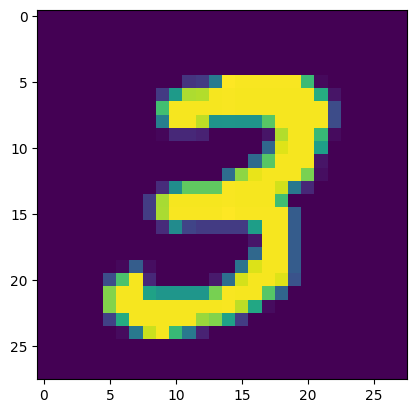

In [4]:
print(f"Image: {plt.imshow(x_train[7])}")

print(f"Labels: {y_train[7]} ")

Images: AxesImage(shape=(28, 28))
Labels: 6


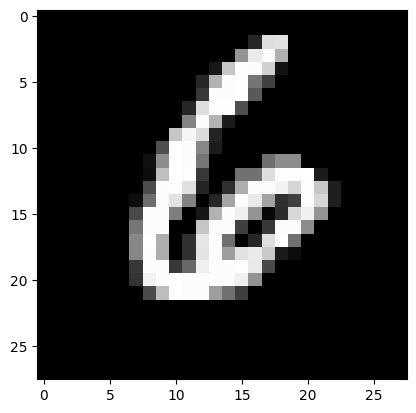

In [5]:
#print with gray color
print(f"Images: {plt.imshow(x_train[13],cmap='gray')}")

print(f"Labels: {y_train[13]}")

# Display Some Sample Images

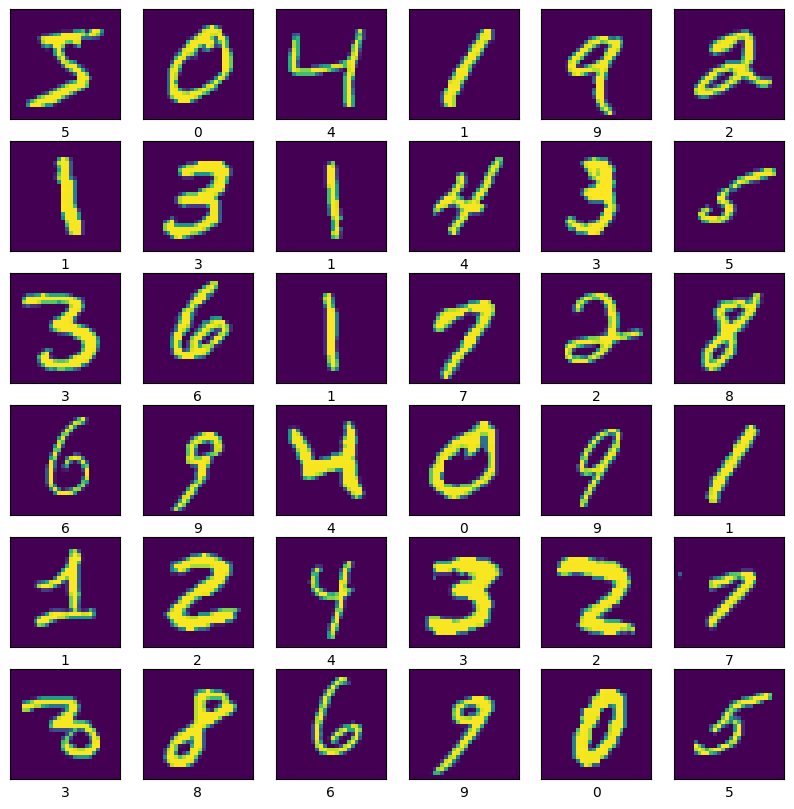

In [6]:
plt.figure(figsize=(10,10))
for i in range(36):
  plt.subplot(6,6,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(x_train[i])
  plt.xlabel(y_train[i])
plt.show()

# Exploratory Data Analysis (EDA)

In [7]:
print(f"""WE Have {len(x_train)} images in train data and {len(x_test)} images in test data.
SImilarly,
We Have {len(y_train)} labels in Train Data and {len(y_test)} labels in Test data.

The size of each image Present in Train and Test data is {x_train[0].shape}""")

WE Have 60000 images in train data and 10000 images in test data.
SImilarly,
We Have 60000 labels in Train Data and 10000 labels in Test data.

The size of each image Present in Train and Test data is (28, 28)


In [8]:
x_train.shape # Shape of x_train

(60000, 28, 28)

In [9]:
x_test.shape #Shape of x_test

(10000, 28, 28)

In [10]:
y_train.shape # Shape of y_Train

(60000,)

In [11]:
y_test.shape # Shape of Y_test

(10000,)

# Printing Random Images From Data

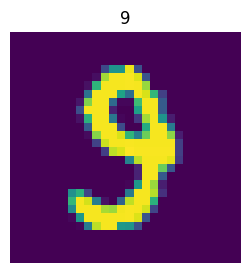

In [12]:
random_images=np.random.randint(0,len(x_train))
plt.figure(figsize=(3,3))
plt.imshow(x_train[random_images])
plt.title(y_train[random_images])
plt.axis(False)
plt.show()

# Displaying  The Image With Their Each Pixel Value

image


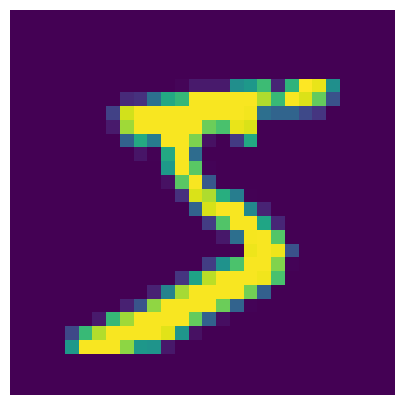

Pixel Values:
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0 
  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0 
  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0 
  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 182 247 241   0   0   

In [13]:
# Display The First Image
print("image")
plt.figure(figsize=(5,5))
plt.imshow(x_train[0])
plt.axis(False)
plt.show()

#Display Each Pixel Value in the image
print("Pixel Values:")
for row in x_train[0]:
  for pixel in row:
    print("{:3}".format(pixel),end=" ")
  print()

# Reshape The Data To Include Color Argument

it is not  color image,it relly in gray scale color category so their color argument will be "1".if the image belongs to RGB Ctegory than the color argumnet will be "3".

Note: The color image Dataset which have color argument "3" are known as high dimenstional dataset and it takes much time for preprocessing

In [14]:
#Reshape the image
x_train=x_train.reshape(x_train.shape+(1,))
x_test=x_test.reshape(x_test.shape+(1,))

x_train.shape,x_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

# Normalizing The Data

Neural Network performs betteron Normalized data.Normalization turns the data into the same scale,in our case, between 0 and 1.


In the case of image,the normalization depends upon the  maximum of the pixels
which is 8 bit. in simplt words,each pixles value must be present between (0-255) range.so we directly take the ratio of the images 255, that sets all the images pixles values in between 0 to 1 that is more suitable for model to perform accurately.

In [15]:
x_train=x_train/255.0
x_test=x_test/255.0

# Changing the data type

In [16]:
x_train=x_train.astype('float32')
x_test=x_test.astype('float32')

# Displaying The image With Their Each Pixel Value After Normalization

image


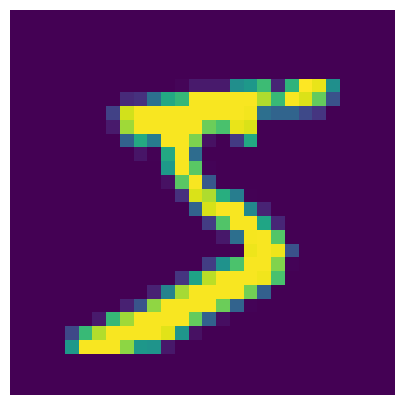

Pixel Values
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.012 0.071 0.071 0.071 0.494 0.533 0.686 0.102 0.651 1.000 0.969 0.49

/tmp/ipykernel_15498/4029267041.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("{:0.3f}".format(float(pixel)),end=" ")


In [17]:
#Displayt The First Image
print('image')
plt.figure(figsize=(5,5))
plt.imshow(x_train[0])
plt.axis(False)
plt.show()

#Display each pixel value in the image
print("Pixel Values")
for row in x_train[0]:
  for pixel in row:
    print("{:0.3f}".format(float(pixel)),end=" ")
  print()

# Data Modeling With CNN

In [18]:
model=tf.keras.Sequential([
    #input layer
    tf.keras.layers.InputLayer(input_shape=(28,28,1)),

    #hidden layer

    #filter is the numbers filters we want to apply
    #kernel is the size of filter moving over the image
    tf.keras.layers.Conv2D(filters=10,kernel_size=(3,3),activation='relu'),#convolutional layer

    tf.keras.layers.Conv2D(filters=10,kernel_size=(3,3),activation='relu'),# convolutional layer

    tf.keras.layers.MaxPool2D(),# Pooling Layer

    tf.keras.layers.Conv2D(filters=10,kernel_size=(3,3),activation='relu'),# convolutional layer

    tf.keras.layers.Conv2D(filters=10,kernel_size=(3,3),activation='relu'),# convolutional layer

    tf.keras.layers.MaxPool2D(), # Pooling Layer

    tf.keras.layers.Flatten(), # Flatten layer

    #output layer

    #In this Mnist Dataset,the goal is to classify handwritten digit (0 to 9),
    #Each image in the dataset represent a digit from 0 to 9, and there are 10 possible classes,
    #because of this reason the output neurons are 10
    tf.keras.layers.Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 10)     │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 10)       │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 10)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,610 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,440 (17.34 KB)

 Trainable params: 4,440 (17.34 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [21]:
history=model.fit(x_train,y_train,epochs=5,batch_size=100,validation_split=0.2)

Epoch 1/5
480/480 ━━━━━━━━━━━━━━━━━━━━ 39s 77ms/step - accuracy: 0.8316 - loss: 0.5491 - val_accuracy: 0.9462 - val_loss: 0.1836
Epoch 2/5
480/480 ━━━━━━━━━━━━━━━━━━━━ 35s 73ms/step - accuracy: 0.9515 - loss: 0.1564 - val_accuracy: 0.9669 - val_loss: 0.1128
Epoch 3/5
480/480 ━━━━━━━━━━━━━━━━━━━━ 43s 77ms/step - accuracy: 0.9663 - loss: 0.1082 - val_accuracy: 0.9747 - val_loss: 0.0856
Epoch 4/5
480/480 ━━━━━━━━━━━━━━━━━━━━ 43s 80ms/step - accuracy: 0.9722 - loss: 0.0877 - val_accuracy: 0.9787 - val_loss: 0.0767
Epoch 5/5
480/480 ━━━━━━━━━━━━━━━━━━━━ 39s 76ms/step - accuracy: 0.9763 - loss: 0.0745 - val_accuracy: 0.9793 - val_loss: 0.0722


# Graph Representation Of Loss & Accuracy

# 1.Loss

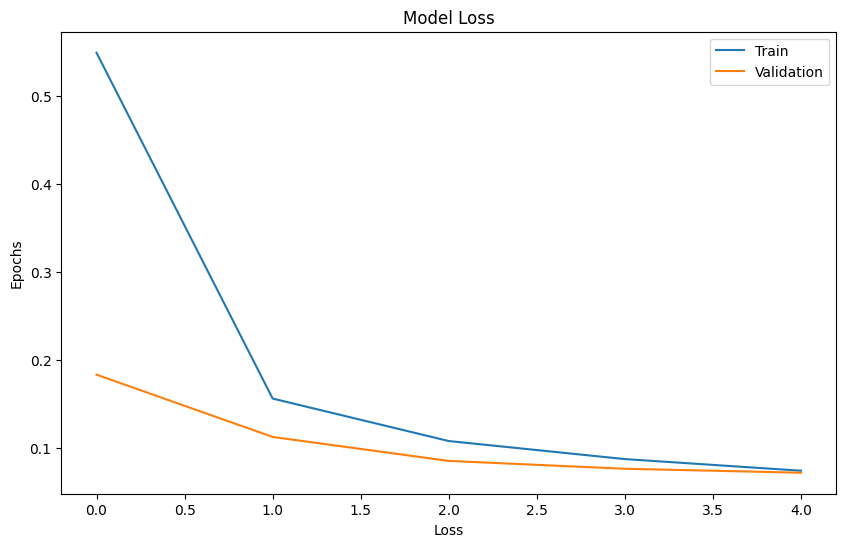

In [22]:
plt.figure(figsize=(10,6))
plt.xlabel('Loss')
plt.ylabel('Epochs')
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train','Validation'],loc='upper right')
plt.title('Model Loss')
plt.show()

# 2. Accuracy

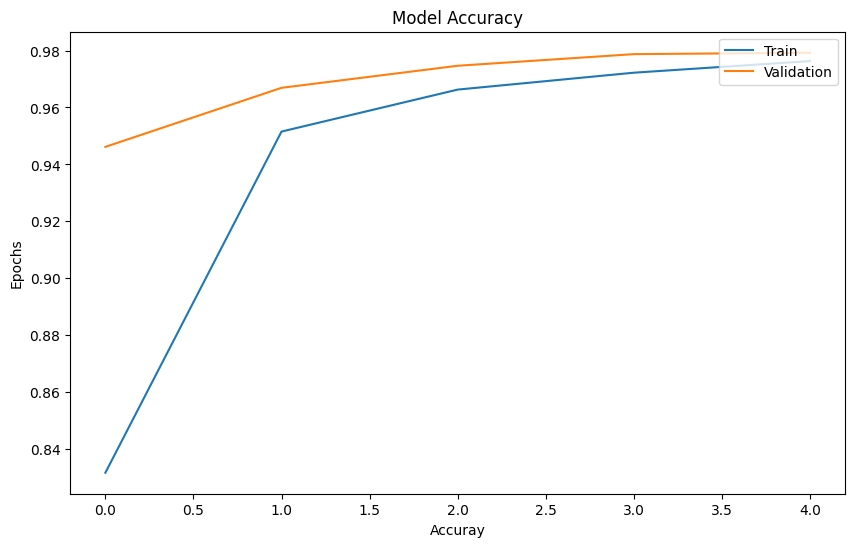

In [23]:
plt.figure(figsize=(10,6))
plt.title('Model Accuracy')
plt.xlabel('Accuray')
plt.ylabel('Epochs')
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'],loc='upper right')
plt.show()

# Model Evaluation For Loss Accuracy On Test Data

In [24]:
loss,accuracy=model.evaluate(x_test,y_test)
print(f"Model Loss:{loss*100}")
print(f"Model Accuracy:{accuracy*100}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9796 - loss: 0.0632
Model Loss:6.318049877882004
Model Accuracy:97.96000123023987


In [25]:
model.save('mnist_model.h5')